In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from shapely import wkt

from pathlib import Path
import uxarray as uxr
import contextily as cx

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   county           174 non-null    str    
 1   waterbody        174 non-null    str    
 2   station          174 non-null    str    
 3   latitude         174 non-null    float64
 4   longitude        174 non-null    float64
 5   geocoded_column  174 non-null    str    
dtypes: float64(2), str(4)
memory usage: 18.2 KB


In [45]:

station_location_resource_code = "cjfb-f4d4"
url = f"https://data.novascotia.ca/resource/{station_location_resource_code}.csv"
df = pd.read_csv(url)
df = df[df['latitude'].between(44,45.25)& df['longitude'].between(-66.75,-65.72)]
df.head()

,county,waterbody,station,latitude,longitude,geocoded_column
28,Digby,St. Marys Bay,1012,44.4071,-66.1605,POINT (-66.1605 44.4071)
29,Digby,St. Marys Bay,5007,44.5391,-65.9580,POINT (-65.958 44.5391)
30,Digby,St. Marys Bay,5008,44.5038,-65.9324,POINT (-65.9324 44.5038)
31,Digby,St. Marys Bay,Centreville 1,44.5328,-65.9840,POINT (-65.984 44.5328)
32,Digby,St. Marys Bay,Centreville,44.5362,-66.0017,POINT (-66.0017 44.5362)


In [46]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geocoded_column']), crs='EPSG:4326')


In [47]:
gdf.describe()

,latitude,longitude
count,13.000000,13.000000
mean,44.423262,-66.098046
std,0.084798,0.098528
min,44.320200,-66.224300
25%,44.350100,-66.160500
50%,44.401700,-66.135700
75%,44.503800,-66.001700
max,44.539100,-65.932400


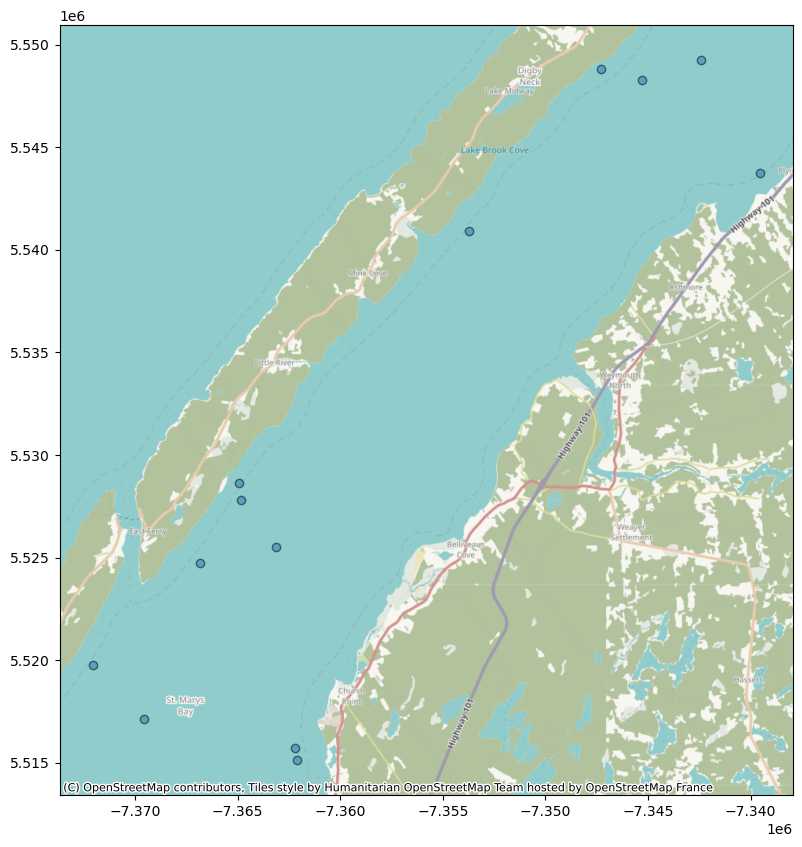

In [48]:
gdf_wm = gdf.to_crs(epsg=3857)

# 3. Create the plot axis
fig, ax = plt.subplots(figsize=(10, 10))
gdf_wm.plot(ax=ax, alpha=0.5, edgecolor="k")

# 4. Add the basemap
cx.add_basemap(ax)
plt.show()

In [4]:

data_path = Path(r"C:\Users\Syed Haque\Documents\GitHub\ohw26_model_downsampling\data\ohw26_model_downsampling_data")
file_name = "stmb_fvcom_2017_05-06.nc"

full_path = data_path / file_name

fvcom_ds = xr.open_dataset(full_path, decode_times= False)

In [9]:
fvcom_ds

<xarray.Dataset> Size: 5GB
Dimensions:             (nele: 31697, node: 17790, siglev: 21, siglay: 20,
                         three: 3, time: 337, maxnode: 10, maxelem: 8, four: 4)
Coordinates:
    lonc                (nele) float32 127kB ...
    latc                (nele) float32 127kB ...
    lon                 (node) float32 71kB ...
    lat                 (node) float32 71kB ...
    siglev              (siglev, node) float32 1MB ...
    siglay              (siglay, node) float32 1MB ...
  * time                (time) float64 3kB 5.787e+04 5.787e+04 ... 5.789e+04
Dimensions without coordinates: nele, node, three, maxnode, maxelem, four
Data variables: (12/48)
    nprocs              int32 4B ...
    partition           (nele) int32 127kB ...
    x                   (node) float32 71kB ...
    y                   (node) float32 71kB ...
    xc                  (nele) float32 127kB ...
    yc                  (nele) float32 127kB ...
    ...                  ...
    vwind_stress        (time, nele) float32 43MB ...
    wet_nodes           (time, node) int32 24MB ...
    wet_cells           (time, nele) int32 43MB ...
    wet_nodes_prev_int  (time, node) int32 24MB ...
    wet_cells_prev_int  (time, nele) int32 43MB ...
    wet_cells_prev_ext  (time, nele) int32 43MB ...
Attributes: (12/15)
    title:                       St Marys Bay - Fundy aquaculture
    institution:                 School for Marine Science and Technology
    source:                      FVCOM_4.1
    history:                     Wed Mar 23 17:11:10 2022: ncrcat fssr2h_0001...
    references:                  http://fvcom.smast.umassd.edu, http://codfis...
    Conventions:                 CF-1.0
    ...                          ...
    River_Forcing:               THERE ARE 8 RIVERS IN THIS MODEL.\nRIVER INF...
    GroundWater_Forcing:         GROUND WATER FORCING IS OFF!
    Surface_Heat_Forcing:        FVCOM variable surface heat forcing file:\nF...
    Surface_Wind_Forcing:        FVCOM variable surface Wind forcing:\nFILE N...
    Surface_PrecipEvap_Forcing:  SURFACE PRECIPITATION FORCING IS OFF
    NCO:                         netCDF Operators version 4.9.1 (Homepage = h...

In [50]:
fvcom_ds0 = fvcom_ds['temp'].isel(time=0, siglay=0)

In [51]:
fvcom_ds0

<xarray.DataArray 'temp' (node: 17790)> Size: 71kB
[17790 values with dtype=float32]
Coordinates:
    lon      (node) float32 71kB ...
    lat      (node) float32 71kB ...
    siglay   (node) float32 71kB ...
    time     float64 8B 5.787e+04
Dimensions without coordinates: node
Attributes:
    long_name:      temperature
    standard_name:  sea_water_temperature
    units:          degrees_C
    grid:           fvcom_grid
    type:           data
    mesh:           fvcom_mesh
    location:       node